In [1]:
%load_ext autoreload
%autoreload 2
    
import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import xgcm
import cartopy.crs as ccrs
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

In [2]:
import cmocean
model2glodap_names = {'cfc12':'cfc12','cfc11':'cfc11','sf6':'sf6','thetao':'theta','so':'salinity'}
variable_kwargs = {
    'cfc12':{'conversion':1e12/1035,'cmap':'Greens','units':'pmol kg-1'}, #originally mol/m^3
    'cfc11':{'conversion':1e12/1035,'cmap':'PuRd','units':'pmol kg-1'},
    'sf6':{'conversion':1e12/1035 * 1e3,'cmap':'Blues','units':'fmol kg-1'},
    'theta':{'conversion':1,'cmap':cmocean.cm.thermal,'units':'degK','bins':np.arange(-2,35,0.2),'anombins':np.arange(-4,4.05,0.05)},
    'thetao':{'conversion':1,'cmap':cmocean.cm.thermal,'units':'deg C','bins':np.arange(-2,35,0.2),'anombins':np.arange(-4,4.05,0.05)},
    'salinity':{'conversion':1,'cmap':cmocean.cm.haline,'units':'psu','bins':np.arange(32,37,0.05),'anombins':np.arange(-1,1.02,0.02)}
}


In [15]:
ds_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/bottom_tracers_yearly.zarr"
ds = xr.open_mfdataset(ds_path).drop_vars(["lon", "lat"])

ds = ds.assign_coords({"lon":1 * ds["geolon"].compute(), "lat":1 * ds["geolat"].compute()})
ds.lon.values[ds.lon.values < -180] = (ds.lon.values[ds.lon.values < -180] + 360) % 360

ds = ds.sel(year = slice(None, 2099))
ds = ds.where(ds.depth < -1200)

ds["sf6"] = 1 * ds["sf6"] * variable_kwargs["sf6"]["conversion"]
ds["cfc11"] = 1 * ds["cfc11"] * variable_kwargs["cfc11"]["conversion"]
ds["cfc12"] = 1 * ds["cfc12"] * variable_kwargs["cfc12"]["conversion"]

ds["sf6"].attrs["units"] = "fmol kg-1"
ds["cfc11"].attrs["units"] = "pmol kg-1"
ds["cfc12"].attrs["units"] = "pmol kg-1"

In [16]:
end_lat, end_lon = -50, 120


start_lat, start_lon = -69, 140
slope = (start_lat - end_lat) / (start_lon- end_lon)

ds_locs_adelie = xr.Dataset()
ds_locs_adelie["lon"] = xr.DataArray(
    data=np.arange(end_lon,start_lon, 0.5), dims=("locations")
)

ds_locs_adelie["lat"] = slope * (ds_locs_adelie["lon"] - start_lon)+ start_lat
ds_locs_adelie["lon"].values = ds_locs_adelie["lon"].values[np.argsort(ds_locs_adelie["lat"])]
ds_locs_adelie["lat"].values = ds_locs_adelie["lat"].values[np.argsort(ds_locs_adelie["lat"])]

start_lat, start_lon = -72, 175
slope = (start_lat - end_lat) / (start_lon- end_lon)

ds_locs_ross = xr.Dataset()
ds_locs_ross["lon"] = xr.DataArray(
    data=np.arange(end_lon,start_lon, 0.5), dims=("locations")
)

ds_locs_ross["lat"] = slope * (ds_locs_ross["lon"] - start_lon)+ start_lat

ds_locs_ross["lon"].values = ds_locs_ross["lon"].values[np.argsort(ds_locs_ross["lat"])]
ds_locs_ross["lat"].values = ds_locs_ross["lat"].values[np.argsort(ds_locs_ross["lat"])]

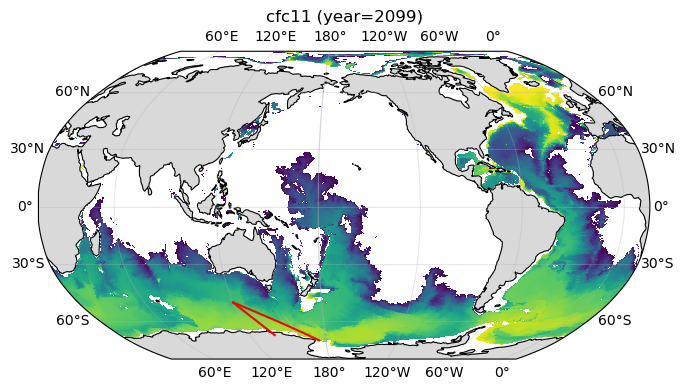

In [17]:
fig, ax = plt.subplots(
    figsize=(10, 4),
    subplot_kw=dict(projection=ccrs.Robinson(central_longitude=-165)),
)

da = ds["cfc11"].isel(expt=0).sel(year = 2020)
da = np.log(da.where(da > 0.001))

pc = ax.pcolormesh(ds["geolon"], ds["geolat"], da,transform=ccrs.PlateCarree(),shading="auto")

ax.plot(ds_locs_adelie["lon"], ds_locs_adelie["lat"],transform=ccrs.PlateCarree(), c="r", zorder=10,)
ax.plot(ds_locs_ross["lon"], ds_locs_ross["lat"],transform=ccrs.PlateCarree(), c="r", zorder=10,)

ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=0)
ax.coastlines(linewidth=0.8)
ax.gridlines(draw_labels = True, alpha = 0.3)
ax.set_title(f"{da.name} (year={int(ds['year'].isel(year=-1).values)})")
fig.tight_layout()

In [18]:
regridder = xe.Regridder(ds, ds_locs_adelie, "bilinear", locstream_out=True)
ds_adelie = regridder(ds).compute()
ds_adelie = ds_adelie.assign_coords({"lon":regridder(ds["lon"]).compute(), 
                                             "lat":regridder(ds["lat"]).compute()})
ds_adelie = ds_adelie.dropna(dim = "locations", how = "all")
ds_adelie = ds_adelie.dropna(dim = "year", how = "all")

In [19]:
regridder = xe.Regridder(ds, ds_locs_ross, "bilinear", locstream_out=True)
ds_ross = regridder(ds).compute()
ds_ross = ds_ross.assign_coords({"lon":regridder(ds["lon"]).compute(), 
                                             "lat":regridder(ds["lat"]).compute()})
ds_ross = ds_ross.dropna(dim = "locations", how = "all")
ds_ross = ds_ross.dropna(dim = "year", how = "all")

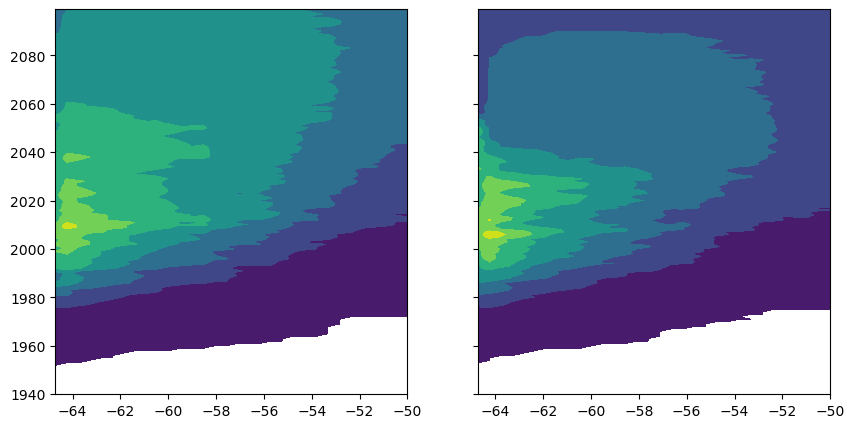

In [20]:
da = ds_adelie["cfc11"]
da = da.where(da > 0.001)
da = da.sel(year = slice(1940, None))

fig, ax = plt.subplots(1, 2, figsize = (10, 5),  sharey = True)
levels = np.arange(0, 1.75 + 0.1, 0.25)

ax[0].contourf(da.lat, da.year, da.sel(expt = "control"), levels = levels)
ax[1].contourf(da.lat, da.year, da.sel(expt = "forced"), levels = levels)

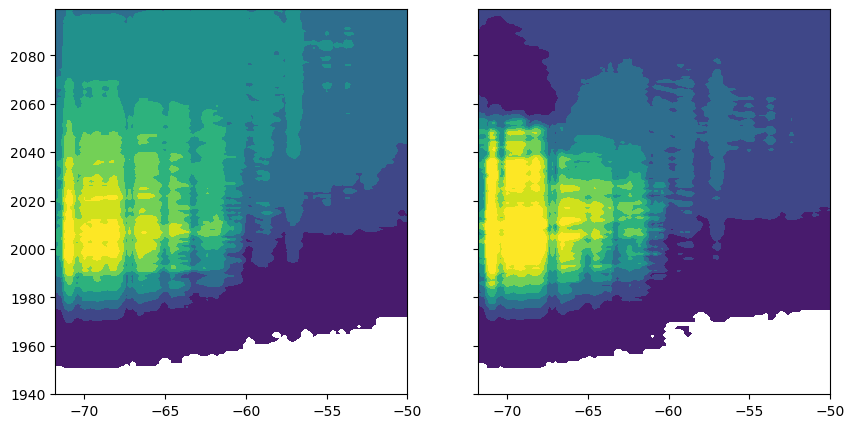

In [21]:
da = ds_ross["cfc11"]
da = da.where(da > 0.001)
da = da.sel(year = slice(1940, None))

fig, ax = plt.subplots(1, 2, figsize = (10, 5),  sharey = True)
levels = np.arange(0, 1.75 + 0.1, 0.25)

ax[0].contourf(da.lat, da.year, da.sel(expt = "control"), levels = levels, extend = "both")
ax[1].contourf(da.lat, da.year, da.sel(expt = "forced"), levels = levels, extend = "both")

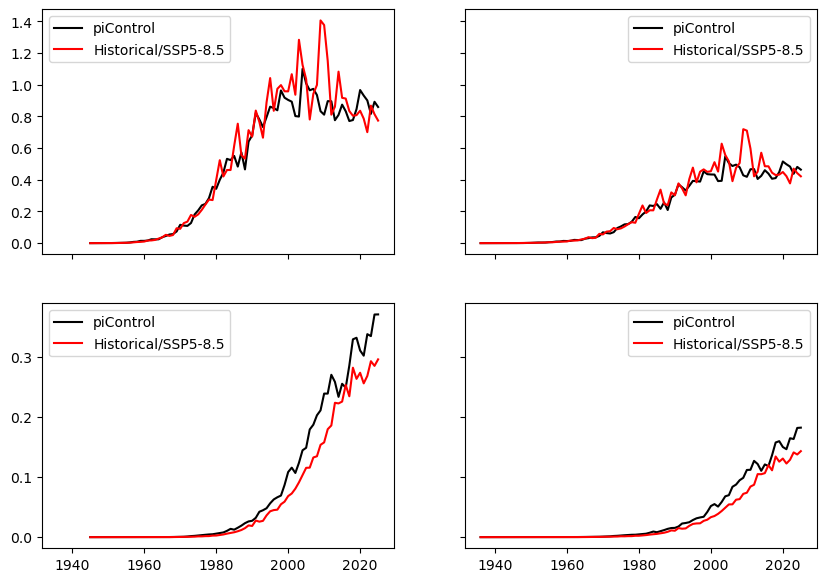

In [22]:
expt_labels = {"control":"piControl", "forced":"Historical/SSP5-8.5"}
expt_colors = {"control":"k", "forced":"r"}

da_slice = 1 * ds_ross.sel(year = slice(None, 2025))

fig, ax = plt.subplots(2, 2, figsize = (10, 7), sharey = "row", sharex = True)

da = da_slice.isel(locations = 0)
# da = da.where(da > 0.01)
da.sel(expt = "control")["cfc11"].plot(ax = ax[0, 0], label = expt_labels["control"], c = expt_colors["control"])
da.sel(expt = "forced")["cfc11"].plot(ax = ax[0, 0], label = expt_labels["forced"], c = expt_colors["forced"])

da.sel(expt = "control")["cfc12"].plot(ax = ax[0, 1],label = expt_labels["control"], c = expt_colors["control"])
da.sel(expt = "forced")["cfc12"].plot(ax = ax[0, 1],label = expt_labels["forced"], c = expt_colors["forced"])


da = da_slice.isel(locations = -1)
# da = da.where(da > 0.01)
da.sel(expt = "control")["cfc11"].plot(ax = ax[1, 0], label = expt_labels["control"], c = expt_colors["control"])
da.sel(expt = "forced")["cfc11"].plot(ax = ax[1, 0], label = expt_labels["forced"], c = expt_colors["forced"])

da.sel(expt = "control")["cfc12"].plot(ax = ax[1, 1],label = expt_labels["control"], c = expt_colors["control"])
da.sel(expt = "forced")["cfc12"].plot(ax = ax[1, 1],label = expt_labels["forced"], c = expt_colors["forced"])
for a in ax.flatten():
    a.legend()
    a.set_ylabel("")
    a.set_xlabel("")
    a.set_title("")

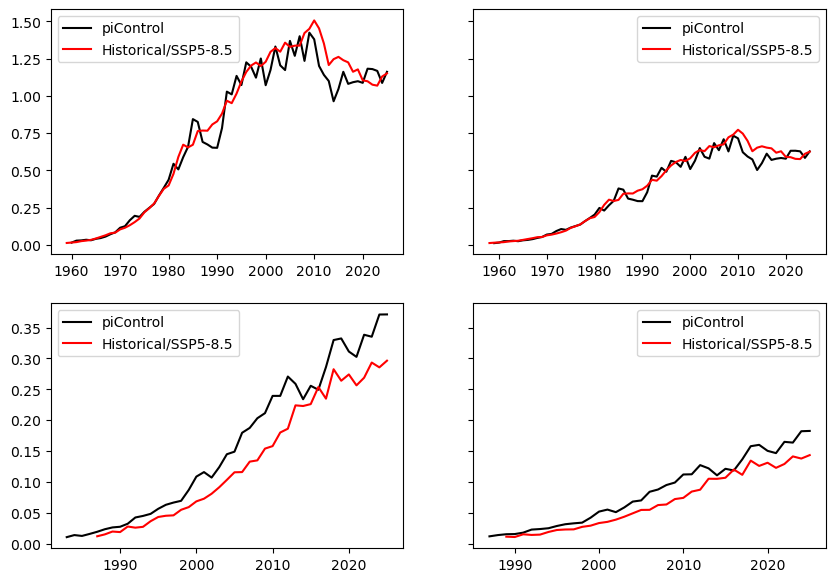

In [23]:
expt_labels = {"control":"piControl", "forced":"Historical/SSP5-8.5"}
expt_colors = {"control":"k", "forced":"r"}

da_slice = ds_adelie.sel(year = slice(None, 2025))

fig, ax = plt.subplots(2, 2, figsize = (10, 7), sharey = "row")

da = da_slice.isel(locations = 0)
da = da.where(da > 0.01)
da.sel(expt = "control")["cfc11"].plot(ax = ax[0, 0], label = expt_labels["control"], c = expt_colors["control"])
da.sel(expt = "forced")["cfc11"].plot(ax = ax[0, 0], label = expt_labels["forced"], c = expt_colors["forced"])

da.sel(expt = "control")["cfc12"].plot(ax = ax[0, 1],label = expt_labels["control"], c = expt_colors["control"])
da.sel(expt = "forced")["cfc12"].plot(ax = ax[0, 1],label = expt_labels["forced"], c = expt_colors["forced"])


da = da_slice.isel(locations = -1)
da = da.where(da > 0.01)
da.sel(expt = "control")["cfc11"].plot(ax = ax[1, 0], label = expt_labels["control"], c = expt_colors["control"])
da.sel(expt = "forced")["cfc11"].plot(ax = ax[1, 0], label = expt_labels["forced"], c = expt_colors["forced"])

da.sel(expt = "control")["cfc12"].plot(ax = ax[1, 1],label = expt_labels["control"], c = expt_colors["control"])
da.sel(expt = "forced")["cfc12"].plot(ax = ax[1, 1],label = expt_labels["forced"], c = expt_colors["forced"])
for a in ax.flatten():
    a.legend()
    a.set_ylabel("")
    a.set_xlabel("")
    a.set_title("")

In [45]:
tracers = ["cfc11", "cfc12", "sf6"]
ds_b_adelie = ds_adelie.isel(locations=0)[tracers].to_array(dim="tracer").expand_dims(source=["adelie"])
ds_b_ross = ds_ross.isel(locations=0)[tracers].to_array(dim="tracer").expand_dims(source=["ross"])
ds_b = xr.concat([ds_b_adelie, ds_b_ross], dim = "source")

#theyre identical because of sampling
ds_i = ds_adelie.isel(locations=-1)[tracers].to_array(dim="tracer")
# ds_i_ross = ds_ross.isel(locations=-1)[tracers].to_array(dim="tracer")

savedir = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/"
savename = savedir + f"adelie_ross_boundary_sample_for_ttd.zarr"
ds_b.to_zarr(savename, compute = True, mode = "w")

savename = savedir + f"adelie_ross_interior_sample_for_ttd.zarr"
ds_i.to_zarr(savename, compute = True, mode = "w")

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter3/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [46]:
ds_i

<xarray.DataArray (tracer: 3, expt: 2, year: 250)> Size: 6kB
array([[[       nan,        nan,        nan, ..., 0.65189344,
         0.6541798 , 0.65006787],
        [       nan,        nan,        nan, ..., 0.43746752,
         0.43725425, 0.43699142]],

       [[       nan,        nan,        nan, ..., 0.37335768,
         0.37615472, 0.37439293],
        [       nan,        nan,        nan, ..., 0.23141545,
         0.23123904, 0.2310076 ]],

       [[       nan,        nan,        nan, ..., 0.9288776 ,
         0.9646811 , 0.97306687],
        [       nan,        nan,        nan, ..., 0.27690282,
         0.27611142, 0.27498344]]], shape=(3, 2, 250), dtype=float32)
Coordinates:
  * tracer   (tracer) object 24B 'cfc11' 'cfc12' 'sf6'
  * expt     (expt) object 16B 'control' 'forced'
  * year     (year) int64 2kB 1850 1851 1852 1853 1854 ... 2096 2097 2098 2099
    z_l      float64 8B 6.5e+03
    lon      float64 8B 120.0
    lat      float64 8B -50.0
Attributes:
    regrid_method:  bilinear